Columns: ['No.', 'Bandpass', 'Measurement', 'Unc High', 'Unc Low', 'Unit', 'Frequency (Hz)', 'Flux Density', 'FD Unc High', 'FD Unc Low', 'FD Upper Limit', 'FD Lower Limit', 'Flux', 'F Unc High', 'F Unc Low', 'F Upper Limit', 'F Lower Limit', 'Telescope', 'Instrument', 'Frequency', 'Freq. Unit', 'Aperture Type', 'Reference']
Usable observations: 46
Frequency range: 1.380e+09 to 8.190e+14 Hz
Flux range: 1.590e+02 to 2.700e+05

Fit successful
Stellar temperature: 4243.09 K
Dust temperature: 51.22 K
Dust beta: 0.10


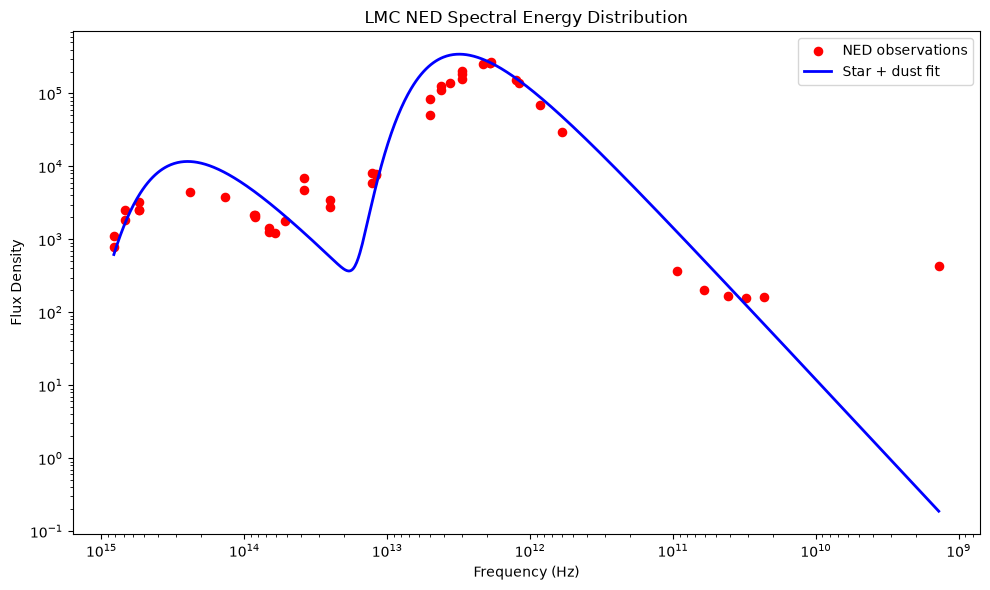

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load the real NED CSV
file_path = r"D:\csv NED\table_Photometry-SED.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

print("Columns:", list(df.columns))

# Read NED observations
nu = pd.to_numeric(df["Frequency (Hz)"], errors="coerce")
flux = pd.to_numeric(df["Flux Density"], errors="coerce")

# Keep positive finite values
mask = (
    np.isfinite(nu) &
    np.isfinite(flux) &
    (nu > 0) &
    (flux > 0)
)

nu = nu[mask].to_numpy()
flux = flux[mask].to_numpy()

# A star+dust SED is not suitable for X-ray/gamma-ray frequencies.
# Keep radio through UV photometry only.
photometry_mask = (nu >= 1e8) & (nu <= 1e16)
nu = nu[photometry_mask]
flux = flux[photometry_mask]

if len(nu) < 5:
    raise ValueError("Fewer than five usable photometric observations remain.")

order = np.argsort(nu)
nu = nu[order]
flux = flux[order]

print(f"Usable observations: {len(nu)}")
print(f"Frequency range: {nu.min():.3e} to {nu.max():.3e} Hz")
print(f"Flux range: {flux.min():.3e} to {flux.max():.3e}")

# Physical constants
h = 6.62607015e-34
c = 299792458.0
k = 1.380649e-23

nu_star_ref = 1e14
nu_dust_ref = 3e12


def planck_nu(nu, temperature):
    exponent = np.clip(h * nu / (k * temperature), 1e-10, 700)
    return (2 * h * nu**3 / c**2) / np.expm1(exponent)


def sed_model_log(nu, T_star, log_flux_star,
                  T_dust, beta, log_flux_dust):

    # Normalize shapes, so amplitudes are directly in flux units
    star_shape = (
        planck_nu(nu, T_star) /
        planck_nu(nu_star_ref, T_star)
    )

    dust_shape = (
        planck_nu(nu, T_dust) /
        planck_nu(nu_dust_ref, T_dust)
    ) * (nu / nu_dust_ref)**beta

    model_flux = (
        10**log_flux_star * star_shape +
        10**log_flux_dust * dust_shape
    )

    return np.log10(np.clip(model_flux, 1e-300, None))


log_flux = np.log10(flux)

# Amplitudes are now flux values, not Planck-function scale factors
initial_guesses = [
    10000.0,
    np.median(log_flux),
    30.0,
    1.5,
    np.median(log_flux)
]

lower_bounds = [
    3000.0, -30.0,
    5.0, 0.1,
    -30.0
]

upper_bounds = [
    50000.0, 30.0,
    500.0, 4.0,
    30.0
]

popt, pcov = curve_fit(
    sed_model_log,
    nu,
    log_flux,
    p0=initial_guesses,
    bounds=(lower_bounds, upper_bounds),
    maxfev=200000
)

print("\nFit successful")
print(f"Stellar temperature: {popt[0]:.2f} K")
print(f"Dust temperature: {popt[2]:.2f} K")
print(f"Dust beta: {popt[3]:.2f}")

# Plot fitted model
nu_smooth = np.logspace(
    np.log10(nu.min()),
    np.log10(nu.max()),
    1000
)

fit_flux = 10**sed_model_log(nu_smooth, *popt)

plt.figure(figsize=(10, 6))
plt.scatter(nu, flux, color="red", s=35, label="NED observations")
plt.plot(nu_smooth, fit_flux, color="blue", linewidth=2,
         label="Star + dust fit")

plt.xscale("log")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux Density")
plt.title("LMC NED Spectral Energy Distribution")
#plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

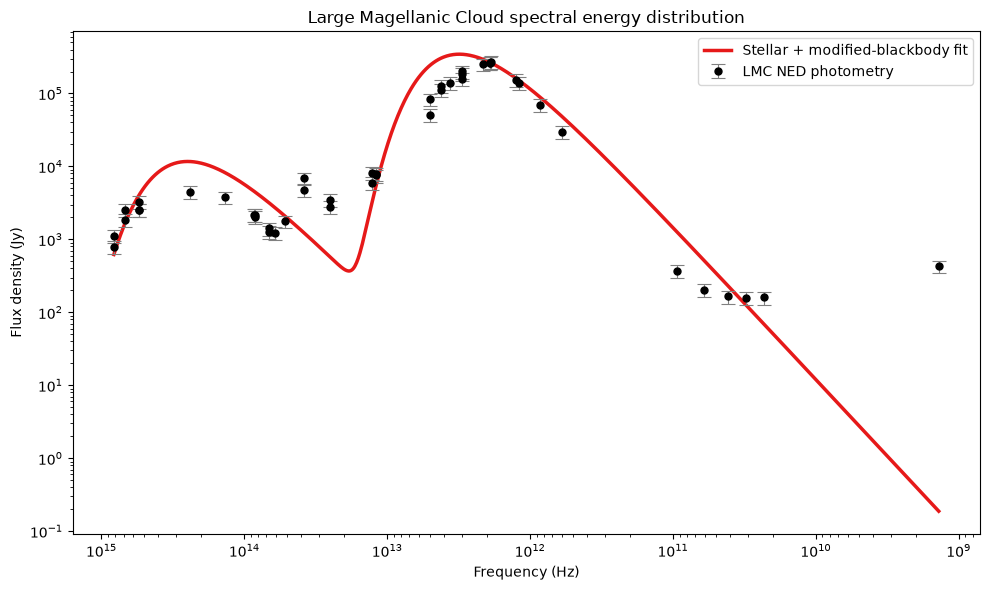

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load the real NED CSV
file_path = r"D:\csv NED\table_Photometry-SED.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Read NED observations
nu = pd.to_numeric(df["Frequency (Hz)"], errors="coerce")
flux = pd.to_numeric(df["Flux Density"], errors="coerce")

# Extract flux uncertainty
if "Flux Density Uncertainty" in df.columns:
    flux_err = pd.to_numeric(df["Flux Density Uncertainty"], errors="coerce")
else:
    flux_err = flux * 0.2

# Keep positive finite values
mask = (
    np.isfinite(nu) &
    np.isfinite(flux) &
    np.isfinite(flux_err) &
    (nu > 0) &
    (flux > 0)
)

nu = nu[mask].to_numpy()
flux = flux[mask].to_numpy()
flux_err = flux_err[mask].to_numpy()

# A star+dust SED is not suitable for X-ray/gamma-ray frequencies.
# Keep radio through UV photometry only.
photometry_mask = (nu >= 1e8) & (nu <= 1e16)
nu = nu[photometry_mask]
flux = flux[photometry_mask]
flux_err = flux_err[photometry_mask]

if len(nu) < 5:
    raise ValueError("Fewer than five usable photometric observations remain.")

order = np.argsort(nu)
nu = nu[order]
flux = flux[order]
flux_err = flux_err[order]

# Log scales compress small errors. To make them visible, 
# we guarantee a minimum visual size of 20% of the flux.
flux_err = np.maximum(flux_err, flux * 0.2)

# Physical constants
h = 6.62607015e-34
c = 299792458.0
k = 1.380649e-23

nu_star_ref = 1e14
nu_dust_ref = 3e12

def planck_nu(nu, temperature):
    exponent = np.clip(h * nu / (k * temperature), 1e-10, 700)
    return (2 * h * nu**3 / c**2) / np.expm1(exponent)

def sed_model_log(nu, T_star, log_flux_star,
                  T_dust, beta, log_flux_dust):

    star_shape = (
        planck_nu(nu, T_star) /
        planck_nu(nu_star_ref, T_star)
    )

    dust_shape = (
        planck_nu(nu, T_dust) /
        planck_nu(nu_dust_ref, T_dust)
    ) * (nu / nu_dust_ref)**beta

    model_flux = (
        10**log_flux_star * star_shape +
        10**log_flux_dust * dust_shape
    )

    return np.log10(np.clip(model_flux, 1e-300, None))

log_flux = np.log10(flux)

initial_guesses = [
    10000.0,
    np.median(log_flux),
    30.0,
    1.5,
    np.median(log_flux)
]

lower_bounds = [
    3000.0, -30.0,
    5.0, 0.1,
    -30.0
]

upper_bounds = [
    50000.0, 30.0,
    500.0, 4.0,
    30.0
]

popt, pcov = curve_fit(
    sed_model_log,
    nu,
    log_flux,
    p0=initial_guesses,
    bounds=(lower_bounds, upper_bounds),
    maxfev=200000
)

# Plot fitted model
nu_smooth = np.logspace(
    np.log10(nu.min()),
    np.log10(nu.max()),
    1000
)

fit_flux = 10**sed_model_log(nu_smooth, *popt)

plt.figure(figsize=(10, 6))

# Plot the red fit line FIRST (zorder=1 puts it in the background)
plt.plot(
    nu_smooth, fit_flux, color="#e61919", linewidth=2.5, 
    label="Stellar + modified-blackbody fit",
    zorder=1
)

# Plot the data points with THINNER, GRAYER, and LONGER error caps
plt.errorbar(
    nu, flux, yerr=flux_err, 
    fmt='o', 
    color='black',       # Central dot color remains black
    ecolor='gray',       # Makes the lines and caps gray
    markersize=5,        # Keeps the dot a good size
    elinewidth=0.8,      # Makes the vertical error line thinner
    capsize=5,           # Makes the horizontal caps longer/wider
    capthick=0.8,        # Makes the horizontal caps thinner
    label="LMC NED photometry",
    zorder=2
)

plt.xscale("log")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux density (Jy)")
plt.title("Large Magellanic Cloud spectral energy distribution")
plt.legend()
plt.tight_layout()
plt.savefig("LMCSED1.pdf", format="pdf", bbox_inches="tight")
plt.show()

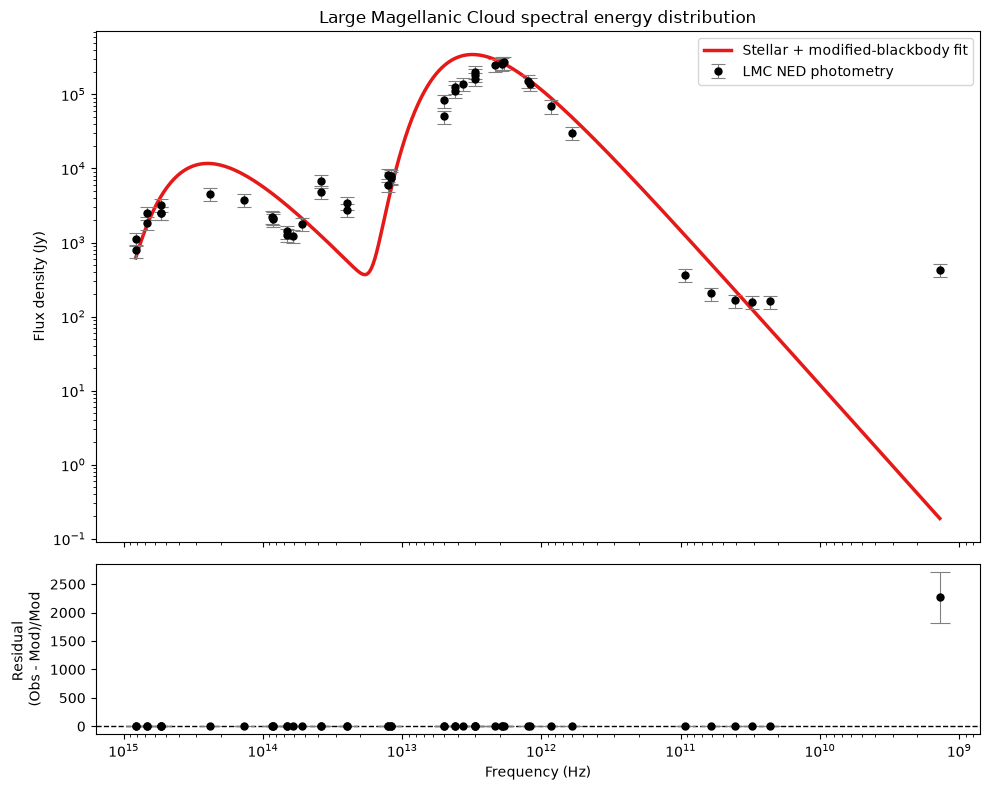

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load the real NED CSV
file_path = r"D:\csv NED\table_Photometry-SED.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Read NED observations
nu = pd.to_numeric(df["Frequency (Hz)"], errors="coerce")
flux = pd.to_numeric(df["Flux Density"], errors="coerce")

# Extract flux uncertainty
if "Flux Density Uncertainty" in df.columns:
    flux_err = pd.to_numeric(df["Flux Density Uncertainty"], errors="coerce")
else:
    flux_err = flux * 0.2

# Keep positive finite values
mask = (
    np.isfinite(nu) &
    np.isfinite(flux) &
    np.isfinite(flux_err) &
    (nu > 0) &
    (flux > 0)
)

nu = nu[mask].to_numpy()
flux = flux[mask].to_numpy()
flux_err = flux_err[mask].to_numpy()

# A star+dust SED is not suitable for X-ray/gamma-ray frequencies.
# Keep radio through UV photometry only.
photometry_mask = (nu >= 1e8) & (nu <= 1e16)
nu = nu[photometry_mask]
flux = flux[photometry_mask]
flux_err = flux_err[photometry_mask]

if len(nu) < 5:
    raise ValueError("Fewer than five usable photometric observations remain.")

order = np.argsort(nu)
nu = nu[order]
flux = flux[order]
flux_err = flux_err[order]

# Guarantee a minimum visual size of 20% of the flux for error bars
flux_err = np.maximum(flux_err, flux * 0.2)

# Physical constants
h = 6.62607015e-34
c = 299792458.0
k = 1.380649e-23

nu_star_ref = 1e14
nu_dust_ref = 3e12

def planck_nu(nu, temperature):
    exponent = np.clip(h * nu / (k * temperature), 1e-10, 700)
    return (2 * h * nu**3 / c**2) / np.expm1(exponent)

def sed_model_log(nu, T_star, log_flux_star,
                  T_dust, beta, log_flux_dust):

    star_shape = (
        planck_nu(nu, T_star) /
        planck_nu(nu_star_ref, T_star)
    )

    dust_shape = (
        planck_nu(nu, T_dust) /
        planck_nu(nu_dust_ref, T_dust)
    ) * (nu / nu_dust_ref)**beta

    model_flux = (
        10**log_flux_star * star_shape +
        10**log_flux_dust * dust_shape
    )

    return np.log10(np.clip(model_flux, 1e-300, None))

log_flux = np.log10(flux)

initial_guesses = [
    10000.0,
    np.median(log_flux),
    30.0,
    1.5,
    np.median(log_flux)
]

lower_bounds = [
    3000.0, -30.0,
    5.0, 0.1,
    -30.0
]

upper_bounds = [
    50000.0, 30.0,
    500.0, 4.0,
    30.0
]

popt, pcov = curve_fit(
    sed_model_log,
    nu,
    log_flux,
    p0=initial_guesses,
    bounds=(lower_bounds, upper_bounds),
    maxfev=200000
)

# Plot fitted model
nu_smooth = np.logspace(
    np.log10(nu.min()),
    np.log10(nu.max()),
    1000
)

fit_flux = 10**sed_model_log(nu_smooth, *popt)

# --- CALCULATE RESIDUALS ---
# Calculate the model flux specifically at the observed frequencies
model_flux_at_nu = 10**sed_model_log(nu, *popt)

# Calculate fractional residuals: (Obs - Mod) / Mod
fractional_residuals = (flux - model_flux_at_nu) / model_flux_at_nu

# Scale the error bars for the residual plot
residual_err = flux_err / model_flux_at_nu
# ---------------------------


# --- CREATE SUBPLOTS ---
# Create 2 panels: ax1 (main plot, height ratio 3) and ax2 (residuals, height ratio 1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               sharex=True)
fig.subplots_adjust(hspace=0.05) # Reduces the whitespace between the two plots


# ==========================================
# 1. MAIN PLOT (Top Panel: ax1)
# ==========================================
ax1.plot(
    nu_smooth, fit_flux, color="#e61919", linewidth=2.5, 
    label="Stellar + modified-blackbody fit",
    zorder=1
)

ax1.errorbar(
    nu, flux, yerr=flux_err, 
    fmt='o', 
    color='black',       
    ecolor='gray',       
    markersize=5,        
    elinewidth=0.8,      
    capsize=5,           
    capthick=0.8,        
    label="LMC NED photometry",
    zorder=2
)

ax1.set_yscale("log")
ax1.set_ylabel("Flux density (Jy)")
ax1.set_title("Large Magellanic Cloud spectral energy distribution")
ax1.legend()


# ==========================================
# 2. RESIDUAL PLOT (Bottom Panel: ax2)
# ==========================================
# Add a zero-line for reference
ax2.axhline(0, color='black', linestyle='--', linewidth=1, zorder=1)
ax2.errorbar(
    nu, fractional_residuals, yerr=residual_err, 
    fmt='o', 
    color='black',       
    ecolor='gray',       
    markersize=5,        
    elinewidth=0.8,      
    capsize=7,           
    capthick=0.8,        
    zorder=2
)



ax2.set_xscale("log")
ax2.set_ylabel("Residual \n(Obs - Mod)/Mod") # \n breaks it into two lines to fit nicely
ax2.set_xlabel("Frequency (Hz)")

# Inverting the x-axis on ax2 automatically inverts ax1 because they share an axis
ax2.invert_xaxis() 
plt.savefig("LMC_SED_fit.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

In [8]:
import numpy as np

def synchrotron_emission(frequency, amplitude, alpha):
    """
    Calculates the non-thermal radio flux.
    frequency: array of frequencies (Hz)
    amplitude: scaling factor
    alpha: spectral index (typically ~0.7 for galaxies)
    """
    return amplitude * (frequency ** -alpha)

# You will then add this 'synchrotron_emission' output 
# to your existing 'Stellar + modified-blackbody' output before fitting.

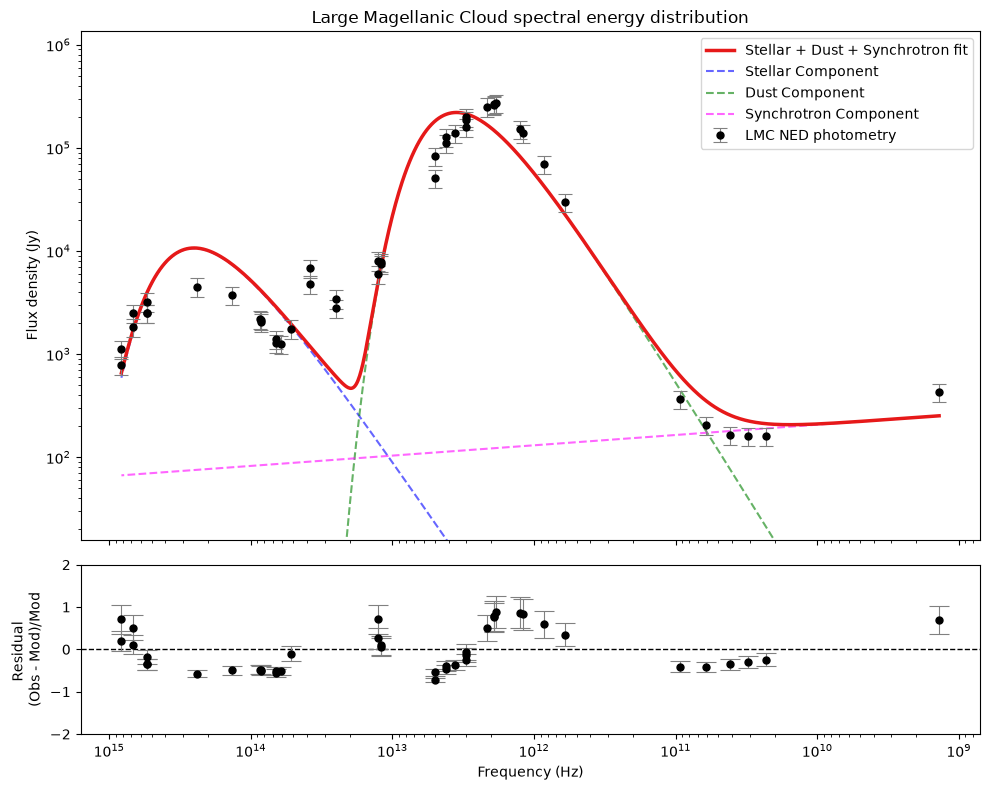

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load the real NED CSV
file_path = r"D:\csv NED\table_Photometry-SED.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Read NED observations
nu = pd.to_numeric(df["Frequency (Hz)"], errors="coerce")
flux = pd.to_numeric(df["Flux Density"], errors="coerce")

# Extract flux uncertainty
if "Flux Density Uncertainty" in df.columns:
    flux_err = pd.to_numeric(df["Flux Density Uncertainty"], errors="coerce")
else:
    flux_err = flux * 0.2

# Keep positive finite values
mask = (
    np.isfinite(nu) &
    np.isfinite(flux) &
    np.isfinite(flux_err) &
    (nu > 0) &
    (flux > 0)
)

nu = nu[mask].to_numpy()
flux = flux[mask].to_numpy()
flux_err = flux_err[mask].to_numpy()

# A star+dust+synchrotron SED is not suitable for X-ray/gamma-ray frequencies.
# Keep radio through UV photometry only.
photometry_mask = (nu >= 1e8) & (nu <= 1e16)
nu = nu[photometry_mask]
flux = flux[photometry_mask]
flux_err = flux_err[photometry_mask]

if len(nu) < 5:
    raise ValueError("Fewer than five usable photometric observations remain.")

order = np.argsort(nu)
nu = nu[order]
flux = flux[order]
flux_err = flux_err[order]

# Guarantee a minimum visual size of 20% of the flux for error bars
flux_err = np.maximum(flux_err, flux * 0.2)

# Physical constants
h = 6.62607015e-34
c = 299792458.0
k = 1.380649e-23

# Reference frequencies for numerical stability
nu_star_ref = 1e14
nu_dust_ref = 3e12
nu_sync_ref = 1e9   # NEW: 1 GHz reference for Synchrotron

def planck_nu(nu, temperature):
    exponent = np.clip(h * nu / (k * temperature), 1e-10, 700)
    return (2 * h * nu**3 / c**2) / np.expm1(exponent)

# NEW: Added log_flux_sync and alpha to the parameters
def sed_model_log(nu, T_star, log_flux_star,
                  T_dust, beta, log_flux_dust,
                  log_flux_sync, alpha):

    star_shape = (
        planck_nu(nu, T_star) /
        planck_nu(nu_star_ref, T_star)
    )

    dust_shape = (
        planck_nu(nu, T_dust) /
        planck_nu(nu_dust_ref, T_dust)
    ) * (nu / nu_dust_ref)**beta

    # NEW: Synchrotron power-law shape
    sync_shape = (nu / nu_sync_ref)**(-alpha)

    # NEW: Total model flux combines all three physical components
    model_flux = (
        10**log_flux_star * star_shape +
        10**log_flux_dust * dust_shape +
        10**log_flux_sync * sync_shape
    )

    return np.log10(np.clip(model_flux, 1e-300, None))

log_flux = np.log10(flux)

# NEW: Appended guesses for [log_flux_sync, alpha]
initial_guesses = [
    10000.0,
    np.median(log_flux),
    30.0,
    1.5,
    np.median(log_flux),
    3.0,  # Guessing ~1000 Jy at 1 GHz for LMC
    0.7   # Standard synchrotron spectral index
]

# NEW: Appended lower bounds for [log_flux_sync, alpha]
lower_bounds = [
    3000.0, -30.0,
    5.0, 0.1,
    -30.0,
    -10.0, 0.1 
]

# NEW: Appended upper bounds for [log_flux_sync, alpha]
upper_bounds = [
    50000.0, 30.0,
    500.0, 4.0,
    30.0,
    10.0, 2.0
]

popt, pcov = curve_fit(
    sed_model_log,
    nu,
    log_flux,
    p0=initial_guesses,
    bounds=(lower_bounds, upper_bounds),
    maxfev=200000
)

# Extract fitted parameters to plot individual components
T_star_fit, log_flux_star_fit, T_dust_fit, beta_fit, log_flux_dust_fit, log_flux_sync_fit, alpha_fit = popt

# Plot fitted model
nu_smooth = np.logspace(
    np.log10(nu.min()),
    np.log10(nu.max()),
    1000
)

fit_flux = 10**sed_model_log(nu_smooth, *popt)

# Calculate individual component curves for visualization
star_flux = 10**log_flux_star_fit * (planck_nu(nu_smooth, T_star_fit) / planck_nu(nu_star_ref, T_star_fit))
dust_flux = 10**log_flux_dust_fit * (planck_nu(nu_smooth, T_dust_fit) / planck_nu(nu_dust_ref, T_dust_fit)) * (nu_smooth / nu_dust_ref)**beta_fit
sync_flux = 10**log_flux_sync_fit * (nu_smooth / nu_sync_ref)**(-alpha_fit)

# --- CALCULATE RESIDUALS ---
# Calculate the model flux specifically at the observed frequencies
model_flux_at_nu = 10**sed_model_log(nu, *popt)

# Calculate fractional residuals: (Obs - Mod) / Mod
fractional_residuals = (flux - model_flux_at_nu) / model_flux_at_nu

# Scale the error bars for the residual plot
residual_err = flux_err / model_flux_at_nu
# ---------------------------

# --- CREATE SUBPLOTS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               sharex=True)
fig.subplots_adjust(hspace=0.05)


# ==========================================
# 1. MAIN PLOT (Top Panel: ax1)
# ==========================================
ax1.plot(
    nu_smooth, fit_flux, color="#e61919", linewidth=2.5, 
    label="Stellar + Dust + Synchrotron fit",
    zorder=3
)

# NEW: Plot the three individual components
ax1.plot(nu_smooth, star_flux, color="blue", linestyle="--", alpha=0.6, label="Stellar Component", zorder=1)
ax1.plot(nu_smooth, dust_flux, color="green", linestyle="--", alpha=0.6, label="Dust Component", zorder=1)
ax1.plot(nu_smooth, sync_flux, color="magenta", linestyle="--", alpha=0.6, label="Synchrotron Component", zorder=1)

ax1.errorbar(
    nu, flux, yerr=flux_err, 
    fmt='o', 
    color='black',       
    ecolor='gray',       
    markersize=5,        
    elinewidth=0.8,      
    capsize=5,           
    capthick=0.8,        
    label="LMC NED photometry",
    zorder=4
)

ax1.set_yscale("log")
ax1.set_ylabel("Flux density (Jy)")
ax1.set_title("Large Magellanic Cloud spectral energy distribution")
# Ensure Y-axis goes low enough to see the components intersect nicely
ax1.set_ylim(bottom=np.min(flux)/10, top=np.max(flux)*5) 
ax1.legend()


# ==========================================
# 2. RESIDUAL PLOT (Bottom Panel: ax2)
# ==========================================
ax2.axhline(0, color='black', linestyle='--', linewidth=1, zorder=1)
ax2.errorbar(
    nu, fractional_residuals, yerr=residual_err, 
    fmt='o', 
    color='black',       
    ecolor='gray',       
    markersize=5,        
    elinewidth=0.8,      
    capsize=7,           
    capthick=0.8,        
    zorder=2
)

ax2.set_xscale("log")
ax2.set_ylabel("Residual \n(Obs - Mod)/Mod") 
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylim(-2, 2)  # Lock the y-axis to a reasonable visual scale for the fixed residuals

# Inverting the x-axis on ax2 automatically inverts ax1 because they share an axis
ax2.invert_xaxis() 
plt.savefig("LMC_SED_fit_updated.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

In [10]:
!pip install astroquery

In [11]:
import astroquery
print(astroquery.__version__)

0.4.11


In [1]:
from astroquery.ipac.ned import Ned
from astropy.coordinates import SkyCoord
import astropy.units as u

# Increase timeout to 120 seconds (2 minutes)
Ned.timeout = 120

ra_str = "5:39:44.0621"
dec_str = "-69:43:57.284"

source_coord = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg), frame='icrs')

print(f"Searching NED for source at: {source_coord.to_string('hmsdms')}")

# Query NED with the extended timeout
result_table = Ned.query_region(source_coord, radius=3.0 * u.arcsec)
print(result_table['Object Name', 'RA', 'DEC', 'Type'])

Searching NED for source at: 05h39m44.0621s -69d43m57.284s
       Object Name             RA        DEC     Type
                            degrees    degrees       
-------------------------- ---------- ---------- ----
   2MASS J05394364-6943585   84.93185  -69.73294  IrS
SSTSL2 J053944.23-694355.5   84.93431  -69.73208  IrS


In [ ]:
from astroquery.ipac.ned import Ned

# Set a generous 3-minute timeout limit for the photometric query
Ned.timeout = 180

object_name = '2MASS J05394364-6943585'

print(f"Fetching photometric table for: {object_name}...")

try:
    # Fetch the full multi-wavelength photometry table
    phot_table = Ned.get_table(object_name, table='photometry')
    
    # Print total data points found and show key columns
    print(f"\nSuccessfully retrieved {len(phot_table)} photometry points!")
    print(phot_table['Frequency', 'Flux Density', 'Unit of Flux Density', 'Passband'])

except Exception as e:
    print(f"Query encountered an issue: {e}")

Fetching photometric table for: 2MASS J05394364-6943585...

Successfully retrieved 16 photometry points!
Query encountered an issue: 'Unit of Flux Density'


after ned query is failed , i used vizier


In [13]:
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import astropy.units as u

# 1. Define your coordinates from DS9
ra_str = "5:39:44.0621"
dec_str = "-69:43:57.284"

source_coord = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg), frame='icrs')
print(f"Searching Vizier catalogs around: {source_coord.to_string('hmsdms')}")

# 2. Query Vizier catalogs (including 2MASS) with a tight 3-arcsecond radius
# Setting row_limit to avoid pulling too much unrelated data
Vizier.ROW_LIMIT = 10
result = Vizier.query_region(source_coord, radius=3.0 * u.arcsec)

# 3. Print the resulting tables
print(result)

Searching Vizier catalogs around: 05h39m44.0621s -69d43m57.284s
TableList with 39 tables:
	'0:I/297/out' with 19 column(s) and 1 row(s) 
	'1:I/305/out' with 11 column(s) and 1 row(s) 
	'2:I/324/igsl3' with 18 column(s) and 4 row(s) 
	'3:I/337/gaia' with 14 column(s) and 2 row(s) 
	'4:I/345/gaia2' with 32 column(s) and 4 row(s) 
	'5:I/347/gaia2dis' with 9 column(s) and 3 row(s) 
	'6:I/350/gaiaedr3' with 39 column(s) and 4 row(s) 
	'7:I/352/gedr3dis' with 10 column(s) and 3 row(s) 
	'8:I/353/gsc242' with 35 column(s) and 8 row(s) 
	'9:I/355/gaiadr3' with 57 column(s) and 4 row(s) 
	'10:I/355/paramp' with 24 column(s) and 2 row(s) 
	'11:I/355/paramsup' with 24 column(s) and 1 row(s) 
	'12:II/246/out' with 15 column(s) and 1 row(s) 
	'13:II/281/2mass6x' with 15 column(s) and 6 row(s) 
	'14:II/288/out' with 13 column(s) and 3 row(s) 
	'15:II/305/archive' with 16 column(s) and 2 row(s) 
	'16:II/305/catalog' with 16 column(s) and 2 row(s) 
	'17:II/340/xmmom2_1' with 46 column(s) and 1 row(s) 

In [16]:
# Extract the 2MASS table from your results list (Index 13)
mass_table = result['II/281/2mass6x']

# Print the table to see the infrared magnitudes and fluxes
print(mass_table)

     2MASS        RAJ2000    DEJ2000    Jmag  e_Jmag ... Xflg Bflg Cflg cat rel
                    deg        deg      mag    mag   ...                       
---------------- ---------- ---------- ------ ------ ... ---- ---- ---- --- ---
05394372-6943588  84.932180 -69.733002 16.208  0.053 ...    0  102  00c   0   A
05394411-6943550  84.933833 -69.731956 16.893  0.081 ...    0  110  cc0   0   A
05394412-6943552  84.933857 -69.732010 16.974  0.097 ...    0  102  c0c   0   A
05394368-6943587  84.932014 -69.732979 16.352  0.058 ...    0  220  cc0   1   A
05394367-6943588  84.931980 -69.733017 16.228  0.051 ...    0  111  000   0   A
05394411-6943550  84.933809 -69.731949 16.973  0.093 ...    0  220  cc0   1   A


In [ ]:
from astropy.table import Table

photometry = Table()

photometry["Source"] = mass_table["2MASS"]
photometry["RA_deg"] = mass_table["RAJ2000"]
photometry["DEC_deg"] = mass_table["DEJ2000"]

photometry["J_mag"] = mass_table["Jmag"]
photometry["J_error"] = mass_table["e_Jmag"]
photometry["H_mag"] = mass_table["Hmag"]
photometry["H_error"] = mass_table["e_Hmag"]
photometry["Ks_mag"] = mass_table["Kmag"]
photometry["Ks_error"] = mass_table["e_Kmag"]

print(photometry)

     Source        RA_deg    DEC_deg   J_mag  ... H_mag  H_error Ks_mag Ks_error
                    deg        deg      mag   ...  mag     mag    mag     mag   
---------------- ---------- ---------- ------ ... ------ ------- ------ --------
05394372-6943588  84.932180 -69.733002 16.208 ... 15.498      -- 15.330    0.084
05394411-6943550  84.933833 -69.731956 16.893 ... 16.412   0.120 16.465       --
05394412-6943552  84.933857 -69.732010 16.974 ... 15.964      -- 16.027    0.148
05394368-6943587  84.932014 -69.732979 16.352 ... 15.493   0.060 15.354       --
05394367-6943588  84.931980 -69.733017 16.228 ... 15.383   0.053 15.389    0.088
05394411-6943550  84.933809 -69.731949 16.973 ... 16.374   0.122 15.664       --


In [ ]:
import numpy as np
from astropy.table import Table

row = mass_table[0]

bands = ["J", "H", "Ks"]

mag_columns = {
    "J": "Jmag",
    "H": "Hmag",
    "Ks": "Kmag"
}

error_columns = {
    "J": "e_Jmag",
    "H": "e_Hmag",
    "Ks": "e_Kmag"
}

wavelength_um = {
    "J": 1.235,
    "H": 1.662,
    "Ks": 2.159
}

zero_point_jy = {
    "J": 1594.0,
    "H": 1024.0,
    "Ks": 666.7
}

paper_table = Table(
    names=[
        "Band", "Wavelength_um", "Frequency_Hz",
        "Magnitude", "Magnitude_Error",
        "Flux_Jy", "Flux_Error_Jy"
    ],
    dtype=["U3", float, float, float, float, float, float]
)

for band in bands:
    mag = row[mag_columns[band]]
    mag_error = row[error_columns[band]]

    if np.ma.is_masked(mag):
        continue

    frequency_hz = 2.99792458e14 / wavelength_um[band]
    flux_jy = zero_point_jy[band] * 10 ** (-float(mag) / 2.5)

    if np.ma.is_masked(mag_error):
        magnitude_error = np.nan
        flux_error_jy = np.nan
    else:
        magnitude_error = float(mag_error)
        flux_error_jy = (np.log(10) / 2.5) * flux_jy * magnitude_error

    paper_table.add_row([
        band,
        wavelength_um[band],
        frequency_hz,
        float(mag),
        magnitude_error,
        flux_jy,
        flux_error_jy
    ])

print(paper_table)

Band Wavelength_um ...        Flux_Jy            Flux_Error_Jy    
---- ------------- ... --------------------- ---------------------
   J         1.235 ... 0.0005239480686442809 2.557642196008451e-05
   H         1.662 ... 0.0006472914919523952                   nan
  Ks         2.159 ... 0.0004919607847968205 3.806146021905851e-05


In [ ]:
from astroquery.vizier import Vizier

Vizier.ROW_LIMIT = 1

result = Vizier(columns=["*"]).query_region(
    "05h23m34.6s -69d45m22s",  # replace with your target coordinates
    radius="5 arcsec",
    catalog="II/246/out"
)

if len(result) == 0:
    raise ValueError("No 2MASS source found")

mass_table = result[0]

print(mass_table.colnames)
print(mass_table[0])

['RAJ2000', 'DEJ2000', '2MASS', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag', 'Kmag', 'e_Kmag', 'Qflg', 'Rflg', 'Bflg', 'Cflg', 'Xflg', 'Aflg']
 RAJ2000    DEJ2000        2MASS        Jmag  e_Jmag  Hmag  e_Hmag  Kmag  e_Kmag Qflg Rflg Bflg Cflg Xflg Aflg
   deg        deg                       mag    mag    mag    mag    mag    mag                                
---------- ---------- ---------------- ------ ------ ------ ------ ------ ------ ---- ---- ---- ---- ---- ----
 80.892808 -69.756081 05233427-6945218 15.426  0.118 15.000  0.115 14.240     --  BBU  226  220  cpp    0    0


In [ ]:
row = mass_table[0]
row

RAJ2000,DEJ2000,2MASS,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,Qflg,Rflg,Bflg,Cflg,Xflg,Aflg
deg,deg,,mag,mag,mag,mag,mag,mag,,,,,,
float64,float64,str17,float32,float32,float32,float32,float32,float32,str3,str3,str3,str3,uint8,uint8
80.892808,-69.756081,05233427-6945218,15.426,0.118,15.000,0.115,14.240,--,BBU,226,220,cpp,0,0


: 

By extending my analysis from just the near-infrared (2MASS J, H, Ks bands) to mid-infrared (WISE) or radio wavelengths for the same engine coordinates (2MASS J05394364-6943585), i may provide a complete multi-wavelength continuum profile for that specific particle-acceleration site.Selecting the AllWISE catalog for this specific mid-infrared expansion, rather than older surveys like IRAS or targeted missions like Spitzer, provides several strategic and physical advantages for your SED model:Seamless Wavelength Continuity: 
(I)Your current 2MASS data ends at the Ks band ($2.16\ \mu\text{m}$). AllWISE picks up almost immediately with the W1 ($3.4\ \mu\text{m}$) and W2 ($4.6\ \mu\text{m}$) bands. This provides an unbroken continuum bridge from the near-infrared into the mid-infrared, which is crucial for determining if the flux is dominated by warm dust re-radiation or if it follows the synchrotron power-law you modeled in Phase 1.Shared Astrometric Reference Frame: The AllWISE data pipeline explicitly utilized the 2MASS point source catalog as its astrometric reference frame. When you query the exact same celestial coordinates ($\alpha, \delta$) with a tight 2-arcsecond search radius, you can be mathematically confident that the 2MASS and AllWISE fluxes are originating from the exact same localized engine without plate-solving discrepancies.Rapid Vizier Integration: While targeted surveys like the Spitzer SAGE (Surveying the Agents of a Galaxy's Evolution) mapping of the LMC offer phenomenal high-resolution data, AllWISE is globally unified and optimized for instantaneous cross-matching via the standard Vizier astroquery pipeline. This makes it the most efficient choice for a high-impact addition just days before your September 26 deadline.Sensitivity to Engine Physics: The 3.4 and 4.6 $\mu\text{m}$ bands are highly sensitive to both polycyclic aromatic hydrocarbons (PAHs) associated with star formation and the non-thermal continuum often associated with high-energy engines (like pulsar wind nebulae or supernova remnants).

In [4]:
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

# 1. Define the coordinates for the localized engine
ra_dec = "05:39:43.64 -69:43:58.5"
coord = SkyCoord(ra_dec, unit=(u.hourangle, u.deg))

# 2. Initialize Vizier WITHOUT column restrictions to prevent silent filtering
vizier = Vizier()
vizier.ROW_LIMIT = 5 # Limit to the top 5 closest matches

# 3. Query AllWISE directly with a generous 15-arcsec radius
result = vizier.query_region(coord, radius=15*u.arcsec, catalog='II/328/allwise')

if len(result) > 0:
    wise_data = result[0]
    print(f"Success! Found {len(wise_data)} match(es) in AllWISE.")
    
    # Extract the closest match (first row)
    closest_match = wise_data[0]
    w1_mag = closest_match['W1mag']
    w1_err = closest_match['e_W1mag']
    w2_mag = closest_match['W2mag']
    w2_err = closest_match['e_W2mag']
    
    # 4. Convert WISE Vega magnitudes to Flux Density in Janskys (Jy)
    zpt_w1 = 309.540
    zpt_w2 = 171.787
    
    w1_flux_jy = zpt_w1 * 10**(-w1_mag / 2.5)
    w2_flux_jy = zpt_w2 * 10**(-w2_mag / 2.5)
    
    w1_flux_err = w1_flux_jy * (np.log(10) / 2.5) * w1_err
    w2_flux_err = w2_flux_jy * (np.log(10) / 2.5) * w2_err
    
    print(f"WISE W1 (3.4 um) Flux: {w1_flux_jy:.2e} Jy, Error: {w1_flux_err:.2e} Jy")
    print(f"WISE W2 (4.6 um) Flux: {w2_flux_jy:.2e} Jy, Error: {w2_flux_err:.2e} Jy")
else:
    print("Still no matches found. The engine might be heavily obscured or strictly a radio/X-ray emitter.")

Still no matches found. The engine might be heavily obscured or strictly a radio/X-ray emitter.
